# Taller B3-T4 — Redes Neuronales para Forecasting
## Ventana entrada: 90 dias | Ventana salida: 1 dias

- **Parte 1 — Competicion**: entrenar y comparar modelos sobre log-retornos en bruto
- **Parte 2 — Investigacion**: aplicar preprocesado del Taller B3-T1 (Lopez de Prado) y evaluar su efecto


In [1]:
VENTANA_ENTRADA = 90   # dias de entrada
VENTANA_SALIDA  = 1   # dias de salida (promedio)


In [2]:
#Ejecutar solo si se quiere entrenar en GPU
import subprocess, sys, os

# ── Instalar PyTorch con CUDA si no esta disponible ──────────────────
try:
    import torch
    if not torch.cuda.is_available():
        raise RuntimeError('torch sin CUDA')
except (ImportError, RuntimeError):
    subprocess.check_call([
        sys.executable, '-m', 'pip', 'install', '-q',
        'torch', '--index-url', 'https://download.pytorch.org/whl/cu128'
    ])
    import torch

# ── Cambiar el backend de Keras a torch ANTES de importar keras ───────
# IMPORTANTE: esta celda debe ejecutarse ANTES de la celda de imports
if 'keras' in sys.modules:
    raise RuntimeError(
        'keras ya fue importado con otro backend. '
        'Reinicia el kernel, ejecuta ESTA celda primero y luego la de imports.'
    )
os.environ['KERAS_BACKEND'] = 'torch'

# ── Verificar GPU ─────────────────────────────────────────────────────
import torch
if not torch.cuda.is_available():
    raise RuntimeError('CUDA no disponible. Revisa la instalacion de PyTorch+CUDA.')

gpu_name = torch.cuda.get_device_name(0)
vram_gb  = torch.cuda.get_device_properties(0).total_memory / 1e9
print(f'GPU: {gpu_name}  ({vram_gb:.1f} GB VRAM)')
print(f'CUDA: {torch.version.cuda}  |  PyTorch: {torch.__version__}')

# ── Verificar que un tensor de prueba va realmente a GPU ─────────────
_t = torch.tensor([1.0]).cuda()
assert _t.device.type == 'cuda', 'El tensor no esta en CUDA'
del _t
print('Tensor de prueba en CUDA: OK')

# ── Verificar backend de Keras tras importarlo ────────────────────────
import keras
backend_activo = keras.backend.backend()
if backend_activo != 'torch':
    raise RuntimeError(
        f'Backend de Keras es "{backend_activo}", se esperaba "torch". '
        'Reinicia el kernel y ejecuta esta celda antes que la de imports.'
    )
print(f'Backend Keras: {backend_activo}  ->  entrenamiento en GPU activado')


GPU: NVIDIA GeForce RTX 5080 Laptop GPU  (17.1 GB VRAM)
CUDA: 12.8  |  PyTorch: 2.11.0+cu128
Tensor de prueba en CUDA: OK
Backend Keras: torch  ->  entrenamiento en GPU activado


In [2]:
import sys
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from scipy.optimize import minimize_scalar
from sklearn.neighbors import KernelDensity
from statsmodels.tsa.stattools import adfuller
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras import regularizers
from utilidades.carga_datos  import cargar_retornos, create_time_series_data, dividir_datos, aplanar_X
from utilidades.modelos      import (
    construir_dense, construir_dense_v2, construir_dense_v3,
    construir_dense_v4, construir_dense_v5, construir_dense_v6,
    construir_recurrente, construir_recurrente_v2, construir_recurrente_v3,
    construir_recurrente_v4, construir_recurrente_v5, construir_recurrente_v6,
    construir_conv1d, construir_conv1d_v2, construir_conv1d_v3,
    construir_conv1d_v4, construir_conv1d_v5, construir_conv1d_v6,
    construir_mixto,
)
from utilidades.evaluacion   import evaluar_modelo, evaluar_sklearn, evaluar_buyhold, guardar_resultados
from utilidades.graficos     import graficar_convergencia, graficar_barras_mae
CALLBACKS = [
    EarlyStopping(patience=10000, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(factor=0.1, patience=500, verbose=1),
]



---
# PARTE 1 — Competicion
Modelos sobre log-retornos en bruto. Metrica: MAE medio sobre 23 activos.


## 1.1 Carga de datos

In [3]:
retornos = cargar_retornos()
X, y = create_time_series_data(retornos, VENTANA_ENTRADA, VENTANA_SALIDA)
print(f'X: {X.shape}  |  y: {y.shape}')
X_train, X_val, X_test, y_train, y_val, y_test = dividir_datos(X, y)
X_train_plano = aplanar_X(X_train)
X_val_plano   = aplanar_X(X_val)
X_test_plano  = aplanar_X(X_test)
print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')


X: (16100, 90, 23)  |  y: (16100, 23)
Train: (13765, 90, 23)  Val: (725, 90, 23)  Test: (1610, 90, 23)


## 1.2 Baselines

In [4]:
reg_lineal = LinearRegression()
reg_lineal.fit(X_train_plano, y_train)
resultado_lineal = evaluar_sklearn(
    reg_lineal, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Lineal')
resultado_bah = evaluar_buyhold(y_train, y_val, y_test)
print(pd.DataFrame([resultado_lineal, resultado_bah]).set_index('modelo').round(6))


            mae_train   mae_val  mae_test  n_params
modelo                                             
Lineal       0.011085  0.010643  0.014020         0
BuyAndHold   0.011700  0.009218  0.012271         0


## 1.3 Modelos Dense (MLP)

In [5]:
def aplicar_hp(modelo, lr=None, l2=None):
    """Aplica lr y/o L2 a un modelo ya construido sin reiniciar Keras."""
    if lr is not None:
        modelo.optimizer.learning_rate.assign(lr)
    if l2 is not None:
        reg = regularizers.l2(l2)
        for layer in modelo.layers:
            if hasattr(layer, "kernel"):
                layer.kernel_regularizer = reg
        # recompila solo la funcion de perdida; el optimizer y sus pesos se conservan
        modelo.compile(optimizer=modelo.optimizer, loss=modelo.loss)


In [34]:
modelo_dense = construir_dense(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense, lr=1e-4, l2=1e-4)
modelo_dense.summary()
hist_dense = modelo_dense.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=100, batch_size=100000, verbose=1)

Model: "Dense"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_77 (Dense)                │ (None, 256)            │       530,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_54 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_78 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_55 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_79 (Dense)                │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 566,039 (2.16 MB)

 Trainable params: 566,039 (2.16 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0210 - val_loss: 0.0143
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 286ms/step - loss: 0.0206 - val_loss: 0.0139
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 383ms/step - loss: 0.0201 - val_loss: 0.0136
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - loss: 0.0197 - val_loss: 0.0132
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 250ms/step - loss: 0.0193 - val_loss: 0.0130
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 268ms/step - loss: 0.0189 - val_loss: 0.0127
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - loss: 0.0185 - val_loss: 0.0125
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 249ms/step - loss: 0.0183 - val_loss: 0.0123
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - loss: 0.0179 - val_loss: 0.0121
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 256ms/step - loss: 0.0177 - val_loss: 0.0119
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 241ms/step - loss: 0.0174 - val_loss: 0.0118
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 242ms/step - loss: 0.0172

{'modelo': 'Dense', 'mae_train': 0.01165967070624278, 'mae_val': 0.009483610124890237, 'mae_test': 0.012691464315585776, 'n_params': 566039}


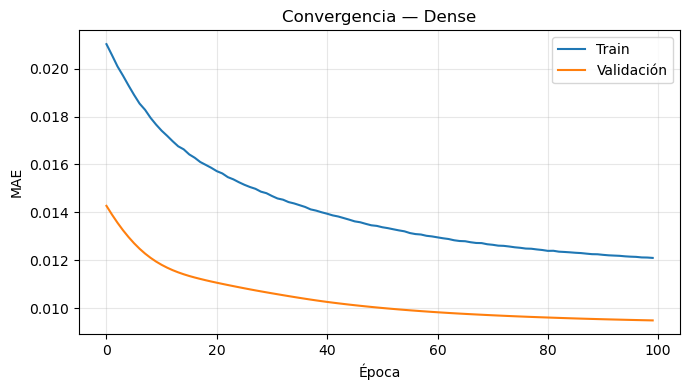

In [35]:
graficar_convergencia(hist_dense, 'Dense')
resultado_dense = evaluar_modelo(modelo_dense, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense')
print(resultado_dense)

### Dense v2 -- 3 capas estrechas (128->64->32), Dropout 0.3

In [ ]:
modelo_dense_v2 = construir_dense_v2(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v2, lr=1e-4, l2=1e-14)
modelo_dense_v2.summary()
hist_dense_v2 = modelo_dense_v2.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=1000, batch_size=13765 , verbose=1)

Model: "Dense_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_48 (Dense)                │ (None, 128)            │       265,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_49 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_37 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_50 (Dense)                │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_38 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_51 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 276,183 (1.05 MB)

 Trainable params: 276,183 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0205 - val_loss: 0.0122
Epoch 2/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.0202 - val_loss: 0.0120
Epoch 3/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0198 - val_loss: 0.0118
Epoch 4/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 149ms/step - loss: 0.0194 - val_loss: 0.0115
Epoch 5/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 127ms/step - loss: 0.0190 - val_loss: 0.0113
Epoch 6/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step - loss: 0.0188 - val_loss: 0.0112
Epoch 7/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0184 - val_loss: 0.0110
Epoch 8/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 120ms/step - loss: 0.0180 - val_loss: 0.0108
Epoch 9/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step - loss: 0.0177 - val_loss: 0.0107
Epoch 10/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - loss: 0.0174 - val_loss: 0.0106
Epoch 11/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step - loss: 0.0171 - val_loss: 0.0105
Epoch 12/1000
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step - 

{'modelo': 'Dense_v2', 'mae_train': 0.011438198250570361, 'mae_val': 0.009233706751933869, 'mae_test': 0.012314383518560856, 'n_params': 276183}


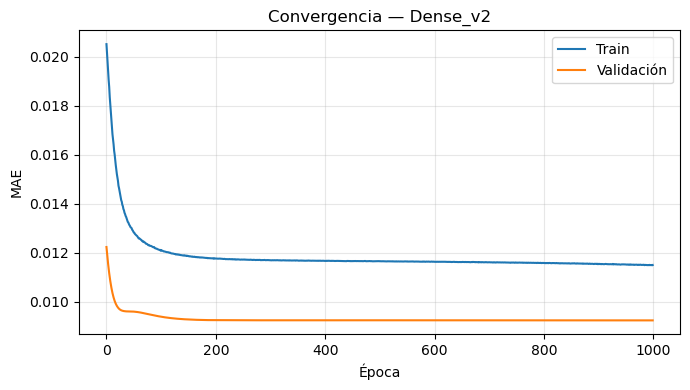

In [36]:
graficar_convergencia(hist_dense_v2, 'Dense_v2')
resultado_dense_v2 = evaluar_modelo(modelo_dense_v2, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v2')
print(resultado_dense_v2)

### Dense v3 -- 4 capas anchas (512->256->128->64), LR=1e-4

In [33]:
modelo_dense_v3 = construir_dense_v3(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v3, lr=1e-4, l2=1e-2)
modelo_dense_v3.summary()
hist_dense_v3 = modelo_dense_v3.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=200, batch_size=13765 ,   verbose=1)

Model: "Dense_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_72 (Dense)                │ (None, 512)            │     1,060,352 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_73 (Dense)                │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_52 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_74 (Dense)                │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_53 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_75 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_76 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,234,327 (4.71 MB)

 Trainable params: 1,234,327 (4.71 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0155 - val_loss: 0.0110
Epoch 2/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 360ms/step - loss: 0.0148 - val_loss: 0.0106
Epoch 3/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 0.0143 - val_loss: 0.0103
Epoch 4/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - loss: 0.0138 - val_loss: 0.0101
Epoch 5/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 329ms/step - loss: 0.0135 - val_loss: 0.0100
Epoch 6/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 394ms/step - loss: 0.0132 - val_loss: 0.0099
Epoch 7/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 385ms/step - loss: 0.0131 - val_loss: 0.0099
Epoch 8/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 335ms/step - loss: 0.0129 - val_loss: 0.0098
Epoch 9/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 341ms/step - loss: 0.0128 - val_loss: 0.0098
Epoch 10/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - loss: 0.0127 - val_loss: 0.0097
Epoch 11/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 354ms/step - loss: 0.0126 - val_loss: 0.0097
Epoch 12/200
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 362ms/step - loss: 0.0125

{'modelo': 'Dense_v3', 'mae_train': 0.011294828829487532, 'mae_val': 0.009265490765367798, 'mae_test': 0.01236345824636126, 'n_params': 1234327}


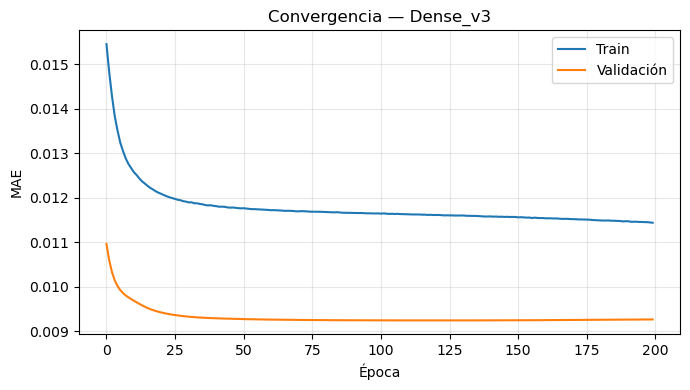

In [37]:
graficar_convergencia(hist_dense_v3, 'Dense_v3')
resultado_dense_v3 = evaluar_modelo(modelo_dense_v3, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v3')
print(resultado_dense_v3)

### Dense v4 -- 2 capas con regularizacion L2 (128->64)

In [47]:
modelo_dense_v4 = construir_dense_v4(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v4, lr=1e-3, l2=1e-4)
modelo_dense_v4.summary()
hist_dense_v4 = modelo_dense_v4.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=400, batch_size=13765 ,   verbose=1)

Model: "Dense_v4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_95 (Dense)                │ (None, 128)            │       265,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_66 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_96 (Dense)                │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_67 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_97 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 274,839 (1.05 MB)

 Trainable params: 274,839 (1.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0555 - val_loss: 0.0457
Epoch 2/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - loss: 0.0515 - val_loss: 0.0430
Epoch 3/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - loss: 0.0482 - val_loss: 0.0411
Epoch 4/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - loss: 0.0456 - val_loss: 0.0397
Epoch 5/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 203ms/step - loss: 0.0437 - val_loss: 0.0385
Epoch 6/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 221ms/step - loss: 0.0420 - val_loss: 0.0375
Epoch 7/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 217ms/step - loss: 0.0407 - val_loss: 0.0365
Epoch 8/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 233ms/step - loss: 0.0394 - val_loss: 0.0355
Epoch 9/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 399ms/step - loss: 0.0382 - val_loss: 0.0345
Epoch 10/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 231ms/step - loss: 0.0371 - val_loss: 0.0335
Epoch 11/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 0.0360 - val_loss: 0.0325
Epoch 12/400
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 197ms/step - loss: 0.0350

{'modelo': 'Dense_v4', 'mae_train': 0.011683037270956431, 'mae_val': 0.009235492540478103, 'mae_test': 0.012282934983635245, 'n_params': 274839}


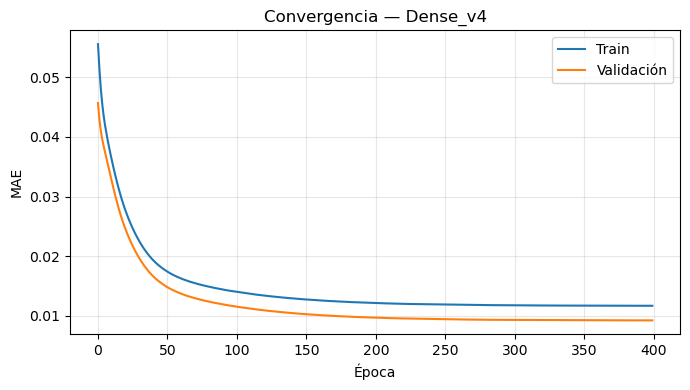

In [48]:
graficar_convergencia(hist_dense_v4, 'Dense_v4')
resultado_dense_v4 = evaluar_modelo(modelo_dense_v4, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v4')
print(resultado_dense_v4)

### Dense v5 -- 1 capa oculta grande (256) con activacion tanh

In [50]:
modelo_dense_v5 = construir_dense_v5(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v5, lr=1e-3, l2=1e-4)
modelo_dense_v5.summary()
hist_dense_v5 = modelo_dense_v5.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=300, batch_size=13765 ,   verbose=1)

Model: "Dense_v5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_100 (Dense)               │ (None, 256)            │       530,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_69 (Dropout)            │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_101 (Dense)               │ (None, 23)             │         5,911 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 536,087 (2.05 MB)

 Trainable params: 536,087 (2.05 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - loss: 0.0291 - val_loss: 0.0201
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 581ms/step - loss: 0.0271 - val_loss: 0.0186
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 234ms/step - loss: 0.0251 - val_loss: 0.0176
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - loss: 0.0238 - val_loss: 0.0169
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 229ms/step - loss: 0.0228 - val_loss: 0.0162
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - loss: 0.0221 - val_loss: 0.0156
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - loss: 0.0213 - val_loss: 0.0151
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - loss: 0.0206 - val_loss: 0.0145
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 247ms/step - loss: 0.0199 - val_loss: 0.0140
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 257ms/step - loss: 0.0191 - val_loss: 0.0135
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - loss: 0.0185 - val_loss: 0.0130
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 405ms/step - loss: 0.0179

{'modelo': 'Dense_v5', 'mae_train': 0.010460885625684766, 'mae_val': 0.010146020988988078, 'mae_test': 0.013416818896065323, 'n_params': 536087}


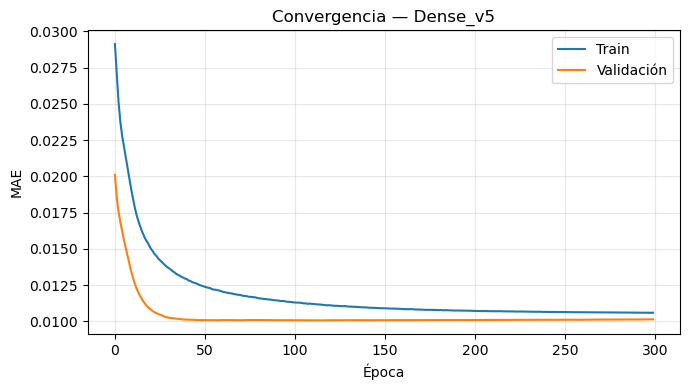

In [51]:
graficar_convergencia(hist_dense_v5, 'Dense_v5')
resultado_dense_v5 = evaluar_modelo(modelo_dense_v5, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v5')
print(resultado_dense_v5)

### Dense v6 -- arquitectura piramidal inversa (32->64->128), activacion elu

In [56]:
modelo_dense_v6 = construir_dense_v6(X_train_plano.shape[1], y_train.shape[1])
aplicar_hp(modelo_dense_v6, lr=5e-4, l2=1e-5)
modelo_dense_v6.summary()
hist_dense_v6 = modelo_dense_v6.fit(X_train_plano, y_train,
    validation_data=(X_val_plano, y_val),
    epochs=300, batch_size=13765 ,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "Dense_v6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_110 (Dense)               │ (None, 32)             │        66,272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_74 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_111 (Dense)               │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_75 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_112 (Dense)               │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_113 (Dense)               │ (None, 23)             │         2,967 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 79,671 (311.21 KB)

 Trainable params: 79,671 (311.21 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 0.0240 - val_loss: 0.0160
Epoch 2/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 200ms/step - loss: 0.0232 - val_loss: 0.0155
Epoch 3/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 222ms/step - loss: 0.0223 - val_loss: 0.0150
Epoch 4/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 251ms/step - loss: 0.0216 - val_loss: 0.0146
Epoch 5/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 181ms/step - loss: 0.0209 - val_loss: 0.0142
Epoch 6/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 175ms/step - loss: 0.0203 - val_loss: 0.0138
Epoch 7/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 156ms/step - loss: 0.0197 - val_loss: 0.0135
Epoch 8/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 176ms/step - loss: 0.0191 - val_loss: 0.0131
Epoch 9/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 224ms/step - loss: 0.0186 - val_loss: 0.0129
Epoch 10/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step - loss: 0.0182 - val_loss: 0.0126
Epoch 11/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - loss: 0.0178 - val_loss: 0.0124
Epoch 12/300
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 218ms/step - loss: 0.0174

{'modelo': 'Dense_v6', 'mae_train': 0.01096948740865263, 'mae_val': 0.009605443765605572, 'mae_test': 0.01272467031806883, 'n_params': 79671}


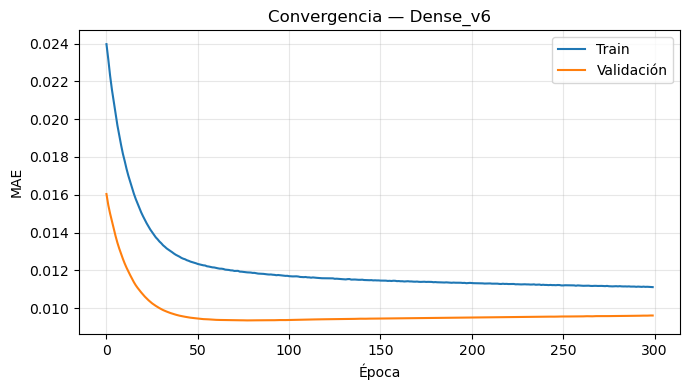

In [57]:
graficar_convergencia(hist_dense_v6, 'Dense_v6')
resultado_dense_v6 = evaluar_modelo(modelo_dense_v6, X_train_plano, y_train,
    X_val_plano, y_val, X_test_plano, y_test, nombre='Dense_v6')
print(resultado_dense_v6)

## 1.4 Modelos Recurrentes (LSTM / GRU)

In [ ]:
modelo_lstm = construir_recurrente(X_train.shape[1:], y_train.shape[1])
modelo_lstm.summary()
hist_lstm = modelo_lstm.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 24,023 (93.84 KB)

 Trainable params: 24,023 (93.84 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


216/216 ━━━━━━━━━━━━━━━━━━━━ 46s 214ms/step - loss: 0.0119 - val_loss: 0.0094
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 56s 260ms/step - loss: 0.0118 - val_loss: 0.0093
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 57s 262ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 52s 243ms/step - loss: 0.0117 - val_loss: 0.0094
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 54s 248ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 55s 255ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 60s 279ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 28s 129ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 9/100
 76/216 ━━━━━━━━━━━━━━━━━━━━ 14s 107ms/step - loss: 0.0118

KeyboardInterrupt: 

{'modelo': 'LSTM', 'mae_train': 0.011808109767611683, 'mae_val': 0.009344719703355736, 'mae_test': 0.012403125116684207, 'n_params': 24023}


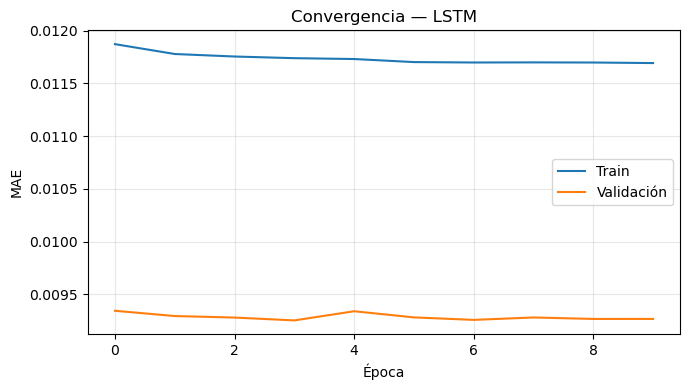

In [ ]:
graficar_convergencia(hist_lstm, 'LSTM')
resultado_lstm = evaluar_modelo(modelo_lstm, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM')
print(resultado_lstm)

### Recurrente v2 -- 2 capas LSTM apiladas (64->32)

In [ ]:
modelo_lstm_v2 = construir_recurrente_v2(X_train.shape[1:], y_train.shape[1])
modelo_lstm_v2.summary()
hist_lstm_v2 = modelo_lstm_v2.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "LSTM_v2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 90, 64)         │        22,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 90, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_15 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_20 (Dense)                │ (None, 23)             │           759 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 35,703 (139.46 KB)

 Trainable params: 35,703 (139.46 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
  1/216 ━━━━━━━━━━━━━━━━━━━━ 1:21 381ms/step - loss: 0.0110

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\backend\torch\rnn.py:651: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, (h_n, c_n) = torch._VF.lstm(


216/216 ━━━━━━━━━━━━━━━━━━━━ 25s 113ms/step - loss: 0.0118 - val_loss: 0.0093
Epoch 2/100
195/216 ━━━━━━━━━━━━━━━━━━━━ 2s 115ms/step - loss: 0.0118

KeyboardInterrupt: 

In [ ]:
graficar_convergencia(hist_lstm_v2, 'LSTM_v2')
resultado_lstm_v2 = evaluar_modelo(modelo_lstm_v2, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v2')
print(resultado_lstm_v2)

### Recurrente v3 -- GRU bidireccional

In [ ]:
modelo_bigru = construir_recurrente_v3(X_train.shape[1:], y_train.shape[1])
modelo_bigru.summary()
hist_bigru = modelo_bigru.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "BiGRU_v3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 64)             │        10,944 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_16 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_21 (Dense)                │ (None, 23)             │         1,495 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,439 (48.59 KB)

 Trainable params: 12,439 (48.59 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100
 12/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0138

c:\Users\1jose\anaconda3\Lib\site-packages\keras\src\backend\torch\rnn.py:853: UserWarning: RNN module weights are not part of single contiguous chunk of memory. This means they need to be compacted at every call, possibly greatly increasing memory usage. To compact weights again call flatten_parameters(). (Triggered internally at C:\actions-runner\_work\pytorch\pytorch\pytorch\aten\src\ATen\native\cudnn\RNN.cpp:1479.)
  outputs, h_n = torch._VF.gru(


216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0123 - val_loss: 0.0094
Epoch 2/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0119 - val_loss: 0.0093
Epoch 3/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0118 - val_loss: 0.0094
Epoch 4/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0118 - val_loss: 0.0093
Epoch 5/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0118 - val_loss: 0.0093
Epoch 6/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0094
Epoch 7/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 8/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 9/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0095
Epoch 10/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 11/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 0.0117 - val_loss: 0.0093
Epoch 12/100
216/216 ━━━━━━━━━━━━━━━━━━━━ 

{'modelo': 'BiGRU_v3', 'mae_train': 0.011582749983968327, 'mae_val': 0.00935050647444267, 'mae_test': 0.012532641120525424, 'n_params': 12439}


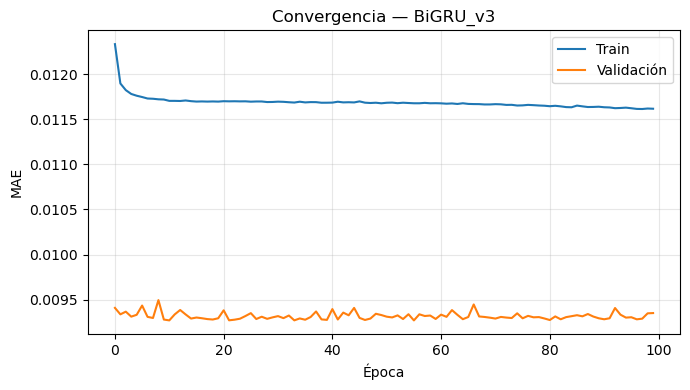

In [ ]:
graficar_convergencia(hist_bigru, 'BiGRU_v3')
resultado_bigru = evaluar_modelo(modelo_bigru, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='BiGRU_v3')
print(resultado_bigru)

### Recurrente v4 -- LSTM + Dense intermedia (64 LSTM -> 32 Dense -> salida)

In [ ]:
modelo_lstm_v4 = construir_recurrente_v4(X_train.shape[1:], y_train.shape[1])
modelo_lstm_v4.summary()
hist_lstm_v4 = modelo_lstm_v4.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_lstm_v4, 'LSTM_v4')
resultado_lstm_v4 = evaluar_modelo(modelo_lstm_v4, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v4')
print(resultado_lstm_v4)

### Recurrente v5 -- LSTM 128 unidades con recurrent_dropout, LR=1e-4

In [ ]:
modelo_lstm_v5 = construir_recurrente_v5(X_train.shape[1:], y_train.shape[1])
modelo_lstm_v5.summary()
hist_lstm_v5 = modelo_lstm_v5.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_lstm_v5, 'LSTM_v5')
resultado_lstm_v5 = evaluar_modelo(modelo_lstm_v5, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='LSTM_v5')
print(resultado_lstm_v5)

### Recurrente v6 -- 2 capas GRU apiladas (64->32)

In [ ]:
modelo_gru_v6 = construir_recurrente_v6(X_train.shape[1:], y_train.shape[1])
modelo_gru_v6.summary()
hist_gru_v6 = modelo_gru_v6.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_gru_v6, 'GRU_v6')
resultado_gru_v6 = evaluar_modelo(modelo_gru_v6, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='GRU_v6')
print(resultado_gru_v6)

## 1.5 Modelos Conv1D

In [ ]:
modelo_conv = construir_conv1d(X_train.shape[1:], y_train.shape[1])
modelo_conv.summary()
hist_conv = modelo_conv.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv, 'Conv1D')
resultado_conv = evaluar_modelo(modelo_conv, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D')
print(resultado_conv)

### Conv1D v2 -- 1 capa Conv1D + Flatten (modelo mas simple)

In [ ]:
modelo_conv_v2 = construir_conv1d_v2(X_train.shape[1:], y_train.shape[1])
modelo_conv_v2.summary()
hist_conv_v2 = modelo_conv_v2.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v2, 'Conv1D_v2')
resultado_conv_v2 = evaluar_modelo(modelo_conv_v2, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v2')
print(resultado_conv_v2)

### Conv1D v3 -- 3 capas Conv1D (64->32->16) + GlobalAveragePooling

In [ ]:
modelo_conv_v3 = construir_conv1d_v3(X_train.shape[1:], y_train.shape[1])
modelo_conv_v3.summary()
hist_conv_v3 = modelo_conv_v3.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v3, 'Conv1D_v3')
resultado_conv_v3 = evaluar_modelo(modelo_conv_v3, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v3')
print(resultado_conv_v3)

### Conv1D v4 -- Conv1D dilatada (dilation_rate=2), campo receptivo ampliado

In [ ]:
modelo_conv_v4 = construir_conv1d_v4(X_train.shape[1:], y_train.shape[1])
modelo_conv_v4.summary()
hist_conv_v4 = modelo_conv_v4.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v4, 'Conv1D_v4')
resultado_conv_v4 = evaluar_modelo(modelo_conv_v4, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v4')
print(resultado_conv_v4)

### Conv1D v5 -- SeparableConv1D (menos parametros, mismo campo receptivo)

In [ ]:
modelo_conv_v5 = construir_conv1d_v5(X_train.shape[1:], y_train.shape[1])
modelo_conv_v5.summary()
hist_conv_v5 = modelo_conv_v5.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v5, 'Conv1D_v5')
resultado_conv_v5 = evaluar_modelo(modelo_conv_v5, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v5')
print(resultado_conv_v5)

### Conv1D v6 -- Conv1D + MaxPooling1D + Flatten

In [ ]:
modelo_conv_v6 = construir_conv1d_v6(X_train.shape[1:], y_train.shape[1])
modelo_conv_v6.summary()
hist_conv_v6 = modelo_conv_v6.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_conv_v6, 'Conv1D_v6')
resultado_conv_v6 = evaluar_modelo(modelo_conv_v6, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Conv1D_v6')
print(resultado_conv_v6)

## 1.6 Modelo Mixto (Conv1D + LSTM)

In [ ]:
modelo_mixto = construir_mixto(X_train.shape[1:], y_train.shape[1])
modelo_mixto.summary()
hist_mixto = modelo_mixto.fit(X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=100, batch_size=64,   verbose=1)

In [ ]:
graficar_convergencia(hist_mixto, 'Mixto')
resultado_mixto = evaluar_modelo(modelo_mixto, X_train, y_train,
    X_val, y_val, X_test, y_test, nombre='Mixto')
print(resultado_mixto)


## 1.7 Resumen de competicion y guardado

In [ ]:
resultados_competicion = [
    resultado_lineal, resultado_bah,
    # Dense
    resultado_dense, resultado_dense_v2, resultado_dense_v3,
    resultado_dense_v4, resultado_dense_v5, resultado_dense_v6,
    # Recurrente
    resultado_lstm, resultado_lstm_v2, resultado_bigru,
    resultado_lstm_v4, resultado_lstm_v5, resultado_gru_v6,
    # Conv1D
    resultado_conv, resultado_conv_v2, resultado_conv_v3,
    resultado_conv_v4, resultado_conv_v5, resultado_conv_v6,
    # Mixto
    resultado_mixto,
]
graficar_barras_mae(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA)
guardar_resultados(resultados_competicion, VENTANA_ENTRADA, VENTANA_SALIDA, seccion='competicion')
display(pd.DataFrame(resultados_competicion).set_index('modelo').round(6))

---
# PARTE 2 — Investigacion
Preprocesado del Taller B3-T1 (Lopez de Prado):
1. **FFD** sobre log-retornos (Snippets 5.3-5.4, *Advances in Financial ML* 2018)
2. **Denoising Marchenko-Pastur** (*ML for Asset Managers* 2020)
3. **StandardScaler** ajustado solo sobre train


## 2.1 Diferenciacion fraccional (FFD)
Se aplica sobre **log-retornos** con ventana maxima de 500 pasos para
garantizar que siempre haya suficientes observaciones tras la transformacion.


In [ ]:
# ── Snippet 5.3: pesos FFD con ventana maxima ───────────────────────────
def get_weights_ffd(d, threshold=1e-5, max_width=None):
    """Pesos para diferenciacion fraccional FFD. max_width limita la ventana."""
    w = [1.0]; k = 1
    while True:
        w_k = -w[-1] * (d - k + 1) / k
        if abs(w_k) < threshold:
            break
        w.append(w_k); k += 1
        if max_width and len(w) >= max_width:
            break
    return np.array(w[::-1])

# ── Snippet 5.4: aplicar FFD ─────────────────────────────────────────────
def frac_diff_ffd(series, d, threshold=1e-5, max_width=None):
    """Aplica FFD a una pd.Series. max_width trunca la ventana de pesos."""
    if max_width is None:
        max_width = len(series)          # no exceder la longitud de la serie
    weights = get_weights_ffd(d, threshold, max_width=max_width)
    width = len(weights)
    if width > len(series):
        return pd.Series(dtype=float)    # serie demasiado corta
    vals = series.values
    # Usar lista en lugar de dict para evitar desalineacion con DatetimeIndex
    result_vals = [
        np.dot(weights, vals[i - width + 1 : i + 1])
        for i in range(width - 1, len(vals))
    ]
    return pd.Series(result_vals, index=series.index[width - 1:])

def encontrar_d_minimo(serie, d_values=None, threshold=1e-5, pvalue=0.05):
    """
    Encuentra el minimo d que hace la serie estacionaria (ADF p-value < pvalue).
    Usa max_width = min(500, len(serie)//2) para que la ventana de pesos nunca
    consuma la serie completa y siempre queden observaciones suficientes.
    """
    if d_values is None:
        d_values = np.arange(0.1, 1.01, 0.1).round(1)
    serie_limpia = serie.replace([np.inf, -np.inf], np.nan).dropna()
    max_w = min(500, len(serie_limpia) // 2)   # ventana maxima: 500 o mitad de la serie
    for d in d_values:
        serie_diff = frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
        serie_diff = serie_diff.replace([np.inf, -np.inf], np.nan).dropna()
        if len(serie_diff) < 20:
            continue
        try:
            adf_pval = adfuller(serie_diff, autolag='AIC')[1]
        except Exception:
            continue
        if adf_pval < pvalue:
            return d, frac_diff_ffd(serie_limpia, d, threshold, max_width=max_w)
    # Fallback: d=1 (primera diferencia), siempre estacionaria para retornos
    return 1.0, frac_diff_ffd(serie_limpia, 1.0, threshold, max_width=max_w)


In [ ]:
# FFD aplicada directamente sobre log-retornos.
# max_width=500 garantiza que la ventana de pesos no consuma la serie entera.

d_values = np.arange(0.1, 1.01, 0.1).round(1)
retornos_ffd = {}
d_optimos = {}

for ticker in retornos.columns:
    d_opt, serie_ffd = encontrar_d_minimo(retornos[ticker], d_values)
    d_optimos[ticker] = d_opt
    retornos_ffd[ticker] = serie_ffd

df_ffd = pd.DataFrame(retornos_ffd).dropna()
df_ffd = df_ffd.loc[:, df_ffd.std() > 1e-10]  # eliminar columnas constantes

print('d optimos por activo:')
print(pd.Series(d_optimos).value_counts().sort_index())
print(f'\nForma tras FFD: {df_ffd.shape}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(list(d_optimos.values()), bins=10, edgecolor='black')
axes[0].set_title('Distribucion de d optimo por activo')
axes[0].set_xlabel('d')
ticker_ej = retornos.columns[0]
axes[1].plot(retornos[ticker_ej].values[:500],  label='Log-retorno original', alpha=0.7)
axes[1].plot(df_ffd[ticker_ej].values[:500],    label=f'FFD (d={d_optimos[ticker_ej]})', alpha=0.7)
axes[1].set_title(f'Log-retorno vs FFD — {ticker_ej}')
axes[1].legend()
plt.tight_layout(); plt.show()


## 2.2 Denoising Marchenko-Pastur
Fuente: Lopez de Prado (2020). La funcion incluye fallbacks para casos
donde la matriz no converge numericamente.


In [ ]:
def mp_pdf(var, q, pts=1000):
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    x = np.linspace(lmin, lmax, pts)
    pdf = q / (2 * np.pi * var * x) * np.sqrt(np.maximum((lmax - x) * (x - lmin), 0))
    return x, pdf, lmax

def fit_kde(obs, bwidth=None, x=None):
    # bwidth adaptativo: 10% del rango de los datos
    if bwidth is None:
        r = obs.max() - obs.min()
        bwidth = max(0.01, r * 0.10)
    kde = KernelDensity(bandwidth=bwidth).fit(obs.reshape(-1, 1))
    if x is None:
        x = np.linspace(obs.min(), obs.max(), 1000)
    return x, np.exp(kde.score_samples(x.reshape(-1, 1)))

def err_pdfs(var, evals, q):
    if var <= 0:
        return 1e10
    lmin = var * (1 - np.sqrt(1 / q)) ** 2
    lmax = var * (1 + np.sqrt(1 / q)) ** 2
    if lmax <= lmin:
        return 1e10
    x_mp, pdf_mp, _ = mp_pdf(var, q)
    _, pdf_kde = fit_kde(evals, x=x_mp)
    return float(np.sum((pdf_kde - pdf_mp) ** 2))

def find_max_eval(evals, q):
    # Normalizar eigenvalues para que el rango de busqueda sea significativo
    evals_flat = evals.flatten()
    evals_mean = evals_flat.mean()
    if evals_mean <= 0:
        evals_mean = 1.0
    evals_norm = evals_flat / evals_mean
    # Buscar var en [0.01, 3] sobre datos normalizados
    best_sse, best_var = np.inf, 1.0
    for var in np.linspace(0.01, 3.0, 60):
        sse = err_pdfs(var, evals_norm, q)
        if sse < best_sse:
            best_sse, best_var = sse, var
    # Refinamiento fino alrededor del mejor
    lo, hi = max(0.001, best_var * 0.5), best_var * 2.0
    try:
        from scipy.optimize import minimize_scalar
        res = minimize_scalar(err_pdfs, bounds=(lo, hi), method='bounded',
                              args=(evals_norm, q))
        if res.success and res.fun < best_sse:
            best_var = res.x
    except Exception:
        pass
    # lmax en escala original
    _, _, lmax_norm = mp_pdf(best_var, q)
    return lmax_norm * evals_mean

def denoised_corr(evals, evecs, n_signal):
    ev = evals.copy()
    noise = ev[n_signal:]
    if len(noise) > 0:
        ev[n_signal:] = noise.mean()
    corr = evecs @ np.diag(ev) @ evecs.T
    diag = np.sqrt(np.diag(corr))
    diag[diag == 0] = 1.0
    corr = corr / np.outer(diag, diag)
    np.fill_diagonal(corr, 1.0)
    return corr

def aplicar_denoising(returns_df):
    """
    Denoising Marchenko-Pastur sobre la matriz de covarianza.
    Devuelve (df_limpio, n_signal, lmax).
    """
    df = returns_df.replace([np.inf, -np.inf], np.nan)
    df = df.dropna(axis=1, how='any')
    df = df.loc[:, df.std() > 1e-10]

    if df.shape[1] < 2 or df.shape[0] < df.shape[1] + 5:
        return returns_df, 0, 1.0

    cov = df.cov().values
    if np.isnan(cov).any() or np.isinf(cov).any():
        return returns_df, 0, 1.0

    N = cov.shape[0]
    T = df.shape[0]
    q = T / N

    std = np.sqrt(np.diag(cov))
    std[std == 0] = 1.0
    corr = np.clip(cov / np.outer(std, std), -1, 1)
    np.fill_diagonal(corr, 1.0)

    try:
        evals, evecs = np.linalg.eigh(corr)
    except np.linalg.LinAlgError:
        print('AVISO: eigh no convergio, se devuelven datos sin denoising')
        return returns_df, 0, 1.0

    # eigh devuelve orden ascendente; invertir para descendente
    idx = np.argsort(evals)[::-1]
    evals, evecs = evals[idx], evecs[:, idx]
    evals = np.maximum(evals, 1e-10)   # evitar eigenvalues negativos por precision

    lmax = find_max_eval(evals.reshape(-1, 1), q)
    n_signal = max(1, min(N - 1, int(np.sum(evals > lmax))))

    corr_clean = denoised_corr(evals, evecs, n_signal)
    corr_clean = np.clip(corr_clean, -1, 1)
    np.fill_diagonal(corr_clean, 1.0)

    cov_clean = corr_clean * np.outer(std, std)
    cov_clean = (cov_clean + cov_clean.T) / 2 + 1e-6 * np.eye(N)

    try:
        L = np.linalg.cholesky(cov_clean)
        returns_clean = df.values @ np.linalg.inv(L).T
    except np.linalg.LinAlgError:
        print('AVISO: Cholesky no convergio, se devuelven datos sin transformar')
        returns_clean = df.values

    result = pd.DataFrame(returns_clean, index=df.index, columns=df.columns)
    for col in returns_df.columns:
        if col not in result.columns:
            result[col] = returns_df[col]
    return result[returns_df.columns], n_signal, lmax


In [ ]:
df_ffd_denoised, n_signal, lmax = aplicar_denoising(df_ffd)
print(f'Autovalores de senyal: {n_signal} / {df_ffd.shape[1]}')
print(f'Lambda_max (Marchenko-Pastur): {lmax:.4f}')

T, N = df_ffd.shape
corr_raw   = np.nan_to_num(df_ffd.corr().values, nan=0.0)
np.fill_diagonal(corr_raw, 1.0)
evals_raw   = np.sort(np.linalg.eigvalsh(corr_raw))[::-1]
corr_clean = np.nan_to_num(df_ffd_denoised.corr().values, nan=0.0)
np.fill_diagonal(corr_clean, 1.0)
evals_clean = np.sort(np.linalg.eigvalsh(corr_clean))[::-1]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(range(N), evals_raw,   color='steelblue', alpha=0.7)
axes[0].axhline(lmax, color='red', linestyle='--', label=f'lambda_max={lmax:.2f}')
axes[0].set_title('Autovalores — antes del denoising'); axes[0].legend()
axes[1].bar(range(N), evals_clean, color='orange', alpha=0.7)
axes[1].set_title('Autovalores — despues del denoising')
plt.tight_layout(); plt.show()


## 2.3 Construccion de ventanas con datos preprocesados

In [ ]:
df_prep = df_ffd_denoised
print(f'Serie preprocesada: {df_prep.shape}')
X_p, y_p = create_time_series_data(df_prep, VENTANA_ENTRADA, VENTANA_SALIDA)
X_tr_p, X_val_p, X_ts_p, y_tr_p, y_val_p, y_ts_p = dividir_datos(X_p, y_p)
n_tr, v, ch = X_tr_p.shape
scaler = StandardScaler()
X_tr_flat  = scaler.fit_transform(X_tr_p.reshape(n_tr, -1))
X_val_flat = scaler.transform(X_val_p.reshape(X_val_p.shape[0], -1))
X_ts_flat  = scaler.transform(X_ts_p.reshape(X_ts_p.shape[0],  -1))
X_tr_3d  = X_tr_flat.reshape(n_tr, v, ch)
X_val_3d = X_val_flat.reshape(X_val_p.shape[0], v, ch)
X_ts_3d  = X_ts_flat.reshape(X_ts_p.shape[0],  v, ch)
print(f'Train: {X_tr_3d.shape}  Val: {X_val_3d.shape}  Test: {X_ts_3d.shape}')


## 2.4 Mejor modelo de Parte 1 re-entrenado con preprocesado

In [ ]:
df_comp = pd.DataFrame(resultados_competicion)
modelos_nn = ('Dense', 'LSTM', 'Conv1D', 'Mixto')
df_nn = df_comp[df_comp['modelo'].isin(modelos_nn)]
mejor_nombre = df_nn.loc[df_nn['mae_test'].idxmin(), 'modelo']
print(f'Mejor modelo Parte 1 (redes neuronales): {mejor_nombre}')
usa_plano = mejor_nombre in ('Dense', 'Lineal')
constructores_prep = {
    'Dense':  lambda: construir_dense(X_tr_flat.shape[1], y_tr_p.shape[1]),
    'LSTM':   lambda: construir_recurrente(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Conv1D': lambda: construir_conv1d(X_tr_3d.shape[1:], y_tr_p.shape[1]),
    'Mixto':  lambda: construir_mixto(X_tr_3d.shape[1:], y_tr_p.shape[1]),
}
modelo_prep = constructores_prep[mejor_nombre]()
X_fit     = X_tr_flat  if usa_plano else X_tr_3d
X_fit_val = X_val_flat if usa_plano else X_val_3d
X_fit_ts  = X_ts_flat  if usa_plano else X_ts_3d
hist_prep = modelo_prep.fit(
    X_fit, y_tr_p,
    validation_data=(X_fit_val, y_val_p),
    epochs=100, batch_size=64,   verbose=1)
graficar_convergencia(hist_prep, f'{mejor_nombre} + FFD + Denoising')
resultado_prep = evaluar_modelo(
    modelo_prep, X_fit, y_tr_p,
    X_fit_val, y_val_p, X_fit_ts, y_ts_p,
    nombre=f'{mejor_nombre}_prep')
print(resultado_prep)


## 2.5 Comparativa con/sin preprocesado y guardado

In [ ]:
resultado_sin_prep = df_comp[df_comp['modelo'] == mejor_nombre].iloc[0].to_dict()
comparativa = pd.DataFrame([resultado_sin_prep, resultado_prep])\
    .set_index('modelo')[['mae_train','mae_val','mae_test','n_params']].round(6)
display(comparativa)
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(3)
ax.bar(x - 0.2, [resultado_sin_prep['mae_train'],
                  resultado_sin_prep['mae_val'],
                  resultado_sin_prep['mae_test']], 0.35,
       label='Sin preprocesado', color='steelblue')
ax.bar(x + 0.2, [resultado_prep['mae_train'],
                  resultado_prep['mae_val'],
                  resultado_prep['mae_test']], 0.35,
       label='FFD + Denoising', color='orange')
ax.set_xticks(x)
ax.set_xticklabels(['MAE Train', 'MAE Val', 'MAE Test'])
ax.set_ylabel('MAE')
ax.set_title(f'{mejor_nombre}: efecto preprocesado B3-T1\n'
             f'Entrada {VENTANA_ENTRADA}d / Salida {VENTANA_SALIDA}d')
ax.legend(); ax.grid(True, axis='y', alpha=0.3)
plt.tight_layout(); plt.show()
mejora = (resultado_sin_prep['mae_test'] - resultado_prep['mae_test']) / resultado_sin_prep['mae_test'] * 100
print(f'Variacion MAE test con preprocesado: {mejora:+.1f}%')
guardar_resultados([resultado_prep], VENTANA_ENTRADA, VENTANA_SALIDA, seccion='investigacion')
